In [40]:
import pandas as pd
import numpy as np
from scipy import stats

In [41]:
df = pd.read_csv('C:/Users/PLUS VAIO/OneDrive/سطح المكتب/work/EV_Charging_Station_Usage.csv')

In [42]:
#City classification
commercial_cities = ['Mumbai', 'Delhi', 'Hyderabad', 'Ahmedabad', 'Pune']
df['City_Type'] = df['City'].apply(lambda x: 'Commercial' if x in commercial_cities else 'Residential/Other')
commercial_cities = ['Mumbai', 'Delhi', 'Hyderabad', 'Ahmedabad', 'Pune']
df['City_Type'] = df['City'].apply(lambda x: 1 if x in commercial_cities else 0)

group1 = df[df['City_Type'] == 1]['Energy_Consumed_kWh'].dropna()
group2 = df[df['City_Type'] == 0]['Energy_Consumed_kWh'].dropna()

m1, m2 = np.mean(group1), np.mean(group2)
s1, s2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
n1, n2 = len(group1), len(group2)

#Confidence Intervals
ci1 = stats.t.interval(0.95, n1-1, loc=m1, scale=stats.sem(group1))
ci2 = stats.t.interval(0.95, n2-1, loc=m2, scale=stats.sem(group2))

# t-test 
t_stat, p_val = stats.ttest_ind(group1, group2)
mean_diff = m1 - m2
d_val = mean_diff / np.sqrt(((s1**2) + (s2**2)) / 2) # Cohen's d المبسط

# results
print(f"{'Group':<20} | {'Mean':<10} | {'95% CI':<20}")
print("-" * 55)
print(f"{'Commercial':<20} | {m1:<10.2f} | [{ci1[0]:.2f}, {ci1[1]:.2f}]")
print(f"{'Residential':<20} | {m2:<10.2f} | [{ci2[0]:.2f}, {ci2[1]:.2f}]")
print("\n" + "="*30)
print(f"P-value: {p_val:.4f}")
print(f"Cohen's d: {d_val:.4f}")
print(f"Mean Difference: {mean_diff:.2f} kWh")

Group                | Mean       | 95% CI              
-------------------------------------------------------
Commercial           | 53.26      | [49.72, 56.81]
Residential          | 52.10      | [48.77, 55.43]

P-value: 0.6386
Cohen's d: 0.0420
Mean Difference: 1.16 kWh


In [43]:
summary_table = df.groupby('City_Type')['Energy_Consumed_kWh'].agg(['mean', 'count']).reset_index()
print(summary_table)

   City_Type       mean  count
0          0  52.102390    251
1          1  53.263052    249


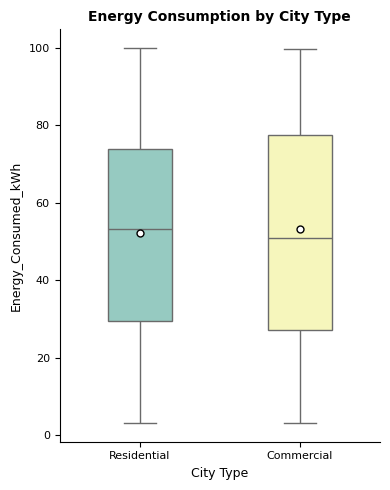

In [45]:
#BOX plot
import seaborn as sns
import matplotlib.pyplot as plt

#figure size
plt.figure(figsize=(4, 5))

sns.boxplot(x='City_Type', y='Energy_Consumed_kWh', data=df, 
            hue='City_Type', palette="Set3", legend=False,
            width=0.4, showmeans=True,
            meanprops={"marker":"o","markerfacecolor":"white", "markeredgecolor":"black", "markersize":"5"})
#lables
plt.title('Energy Consumption by City Type', fontsize=10, fontweight='bold')
plt.xlabel('City Type', fontsize=9)
plt.ylabel('Energy_Consumed_kWh', fontsize=9)

plt.xticks([0, 1], ['Residential', 'Commercial'], fontsize=8)
plt.yticks(fontsize=8)

sns.despine()
plt.tight_layout()

plt.show()

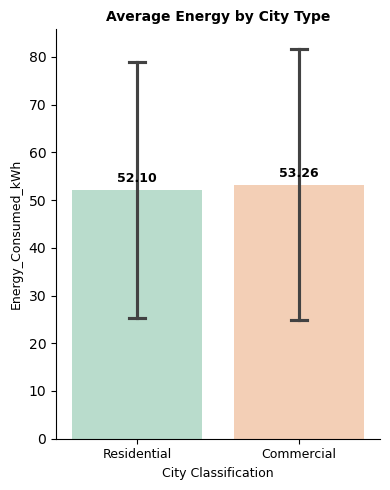

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 5))


sns.barplot(x='City_Type', y='Energy_Consumed_kWh', data=df, 
            hue='City_Type', palette="Pastel2", legend=False,
            errorbar='sd', capsize=0.1) 
means = [52.10, 53.26] 
for i, v in enumerate(means):
    plt.text(i, v + 1, f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Average Energy by City Type', fontsize=10, fontweight='bold')
plt.xticks([0, 1], ['Residential', 'Commercial'], fontsize=9)
plt.ylabel('Energy_Consumed_kWh', fontsize=9)
plt.xlabel('City Classification', fontsize=9)

sns.despine()
plt.tight_layout()

plt.show()

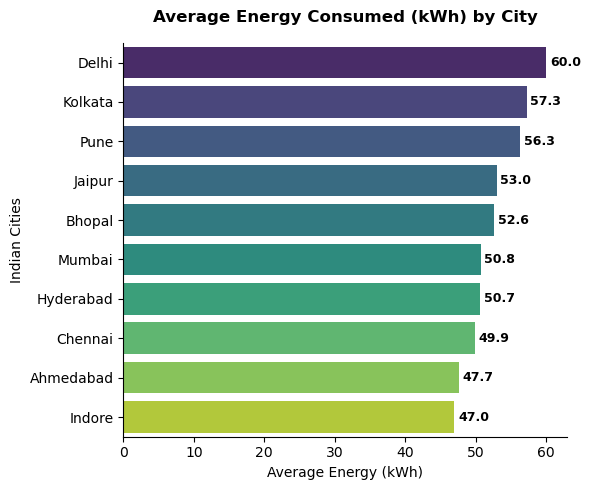

In [47]:
# Means for each city:
city_means = df.groupby('City')['Energy_Consumed_kWh'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(6, 5))

#bar plot design
sns.barplot(x='Energy_Consumed_kWh', y='City', data=city_means, 
            hue='City', palette='viridis', legend=False)

#(Bar Labels)
for i, v in enumerate(city_means['Energy_Consumed_kWh']):
    plt.text(v + 0.5, i, f'{v:.1f}', va='center', fontsize=9, fontweight='bold')

#labels  
plt.title('Average Energy Consumed (kWh) by City', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Average Energy (kWh)', fontsize=10)
plt.ylabel('Indian Cities', fontsize=10)

sns.despine()
plt.tight_layout()

plt.show()

In [48]:
pivot_table = df.pivot_table(values='Energy_Consumed_kWh', 
                             index='City', 
                             columns='Vehicle_Type', 
                             aggfunc='mean').round(2)

print("### Pivot Table: Average Energy (kWh) by City and Vehicle ###")
print(pivot_table)



### Pivot Table: Average Energy (kWh) by City and Vehicle ###
Vehicle_Type   Bike    Bus    Car  Truck
City                                    
Ahmedabad     56.59  40.10  45.94  48.65
Bhopal        43.86  57.12  54.16  60.19
Chennai       45.50  53.81  49.58  50.41
Delhi         47.04  66.55  62.62  66.16
Hyderabad     35.50  67.17  45.65  68.98
Indore        63.31  42.00  32.20  55.79
Jaipur        59.64  46.98  52.36  51.89
Kolkata       67.80  56.25  53.01  54.38
Mumbai        49.88  50.76  52.03  50.85
Pune          58.20  56.85  48.29  60.75


In [49]:
cross_tab = pd.crosstab(df['City'], df['Vehicle_Type'])

print("\n### Cross-tab: Number of Charging Sessions by City and Vehicle ###")
print(cross_tab)


### Cross-tab: Number of Charging Sessions by City and Vehicle ###
Vehicle_Type  Bike  Bus  Car  Truck
City                               
Ahmedabad       14   13   21     10
Bhopal          17   14   12      9
Chennai          8    8   12     15
Delhi           16   11   15     16
Hyderabad       12    6   16      9
Indore           8   11   14     15
Jaipur          14   10   15     19
Kolkata          9   19    9     13
Mumbai          10   13    6     13
Pune            13   11   11     13
